# Predicting Student Health Risk: EDA 및 모델링 계획

**작성자:** 정서현  
**목적:** 2026-09-02 DScover 온라인 회의 공유  
**대회:** [Kaggle Playground Series S6E7](https://www.kaggle.com/competitions/playground-series-s6e7)

이 노트북은 다음 두 가지를 목표로 한다.

1. 학습·시험 데이터의 구조, 결측치, 타깃 불균형 및 주요 변수 관계를 확인한다.
2. EDA 결과를 바탕으로 사용할 분류 모델과 검증 방법을 제안한다.

> **결론 요약:** 데이터는 3개 클래스가 심하게 불균형하고, `stress_level`, `sleep_duration`, `physical_activity_level`, `bmi`에서 뚜렷한 클래스 차이가 관찰된다. 동일 대회의 공개 구현과 실행 여건을 함께 검토한 결과, **TabPFN-3를 성능 중심 주요 후보**, **LightGBM을 비교·검증 모델**, **HistGradientBoosting을 로컬 기준 모델**로 제안한다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)

In [2]:
# 로컬 Jupyter, GitHub 프로젝트, Kaggle Notebook에서 모두 찾을 수 있도록 구성
path_candidates = [
    Path('.'),
    Path('../data'),
    Path('data'),
    Path('../../upload'),
    Path('/kaggle/input/competitions/playground-series-s6e7'),
]

data_dir = next(
    (path for path in path_candidates if (path / 'train.csv').exists()),
    None,
)
if data_dir is None:
    raise FileNotFoundError('train.csv를 찾지 못했습니다. data 폴더에 CSV 파일을 넣어주세요.')

train = pd.read_csv(data_dir / 'train.csv')
test = pd.read_csv(data_dir / 'test.csv')
sample_submission = pd.read_csv(data_dir / 'sample_submission.csv')

print(f'Data directory: {data_dir.resolve()}')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Sample submission shape: {sample_submission.shape}')

Data directory: /workspace/scratch/d25237199cb8/upload
Train shape: (690088, 15)
Test shape: (295753, 14)
Sample submission shape: (295753, 2)


## 1. 데이터 구조 확인

- `train.csv`: 모델이 학습할 데이터로 정답인 `health_condition`이 포함되어 있다.
- `test.csv`: 학습된 모델로 정답을 예측할 데이터다.
- `sample_submission.csv`: Kaggle 제출 파일의 열 이름과 형식을 보여준다.
- `id`는 행 식별자이므로 예측 변수에서는 제외한다.

In [3]:
target = 'health_condition'
features = [c for c in train.columns if c not in ['id', target]]
numeric_features = train[features].select_dtypes(include='number').columns.tolist()
categorical_features = train[features].select_dtypes(exclude='number').columns.tolist()

print('Columns:', train.columns.tolist())
print('\nNumeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('\nDuplicate rows in train:', train.duplicated().sum())
display(train.head())

Columns: ['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

Numeric features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

Duplicate rows in train: 0


id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 2. 타깃 클래스 분포

이 대회의 평가지표는 **Balanced Accuracy**다. 각 클래스의 재현율(Recall)을 구한 뒤 평균을 내므로, 다수 클래스만 맞히는 모델보다 세 클래스를 고르게 맞히는 모델이 중요하다.

,count,ratio (%)
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


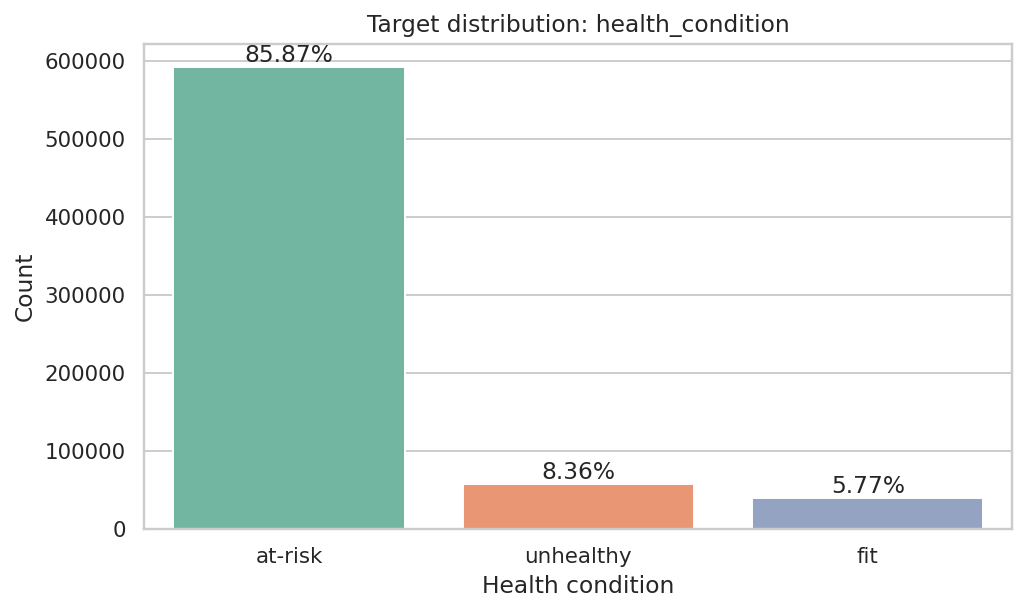

In [4]:
class_order = ['at-risk', 'unhealthy', 'fit']
target_counts = train[target].value_counts().reindex(class_order)
target_summary = pd.DataFrame({
    'count': target_counts,
    'ratio (%)': (target_counts / len(train) * 100).round(2),
})
display(target_summary)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=target_summary.index, y=target_summary['count'], palette='Set2')
ax.set_title('Target distribution: health_condition')
ax.set_xlabel('Health condition')
ax.set_ylabel('Count')
for patch, value in zip(ax.patches, target_summary['ratio (%)']):
    ax.annotate(f'{value:.2f}%',
                (patch.get_x() + patch.get_width()/2, patch.get_height()),
                ha='center', va='bottom')
plt.show()

### 해석

- `at-risk`가 **85.87%**로 대부분을 차지한다.
- 반대로 `unhealthy`는 **8.36%**, `fit`은 **5.77%**에 불과하다.
- 따라서 단순 정확도(Accuracy)만 사용하면 다수 클래스에 치우친 모델을 좋은 모델로 착각할 수 있다.
- 검증 데이터는 `StratifiedKFold` 또는 `stratify=y`를 사용해 클래스 비율을 유지하고, 성능은 Balanced Accuracy로 평가해야 한다.

## 3. 결측치 확인

,missing_count,missing_ratio (%)
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


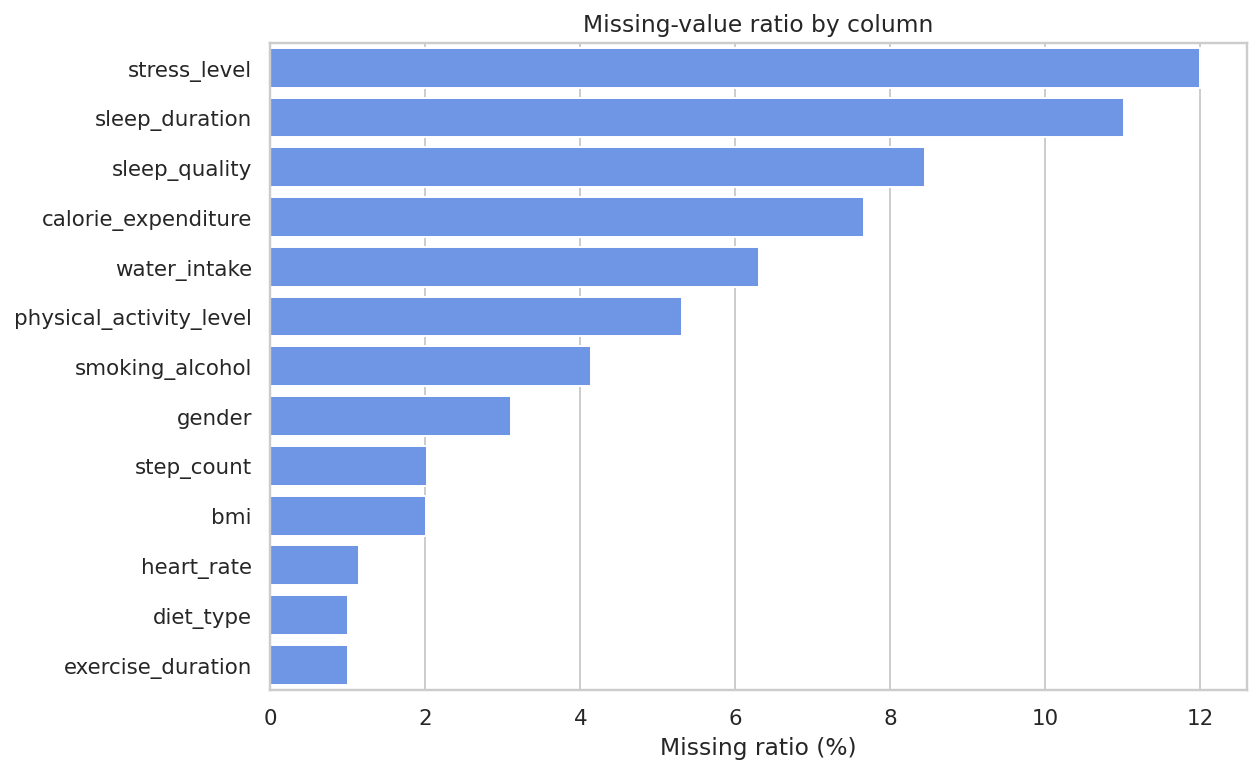

In [5]:
missing_summary = pd.DataFrame({
    'missing_count': train.isna().sum(),
    'missing_ratio (%)': (train.isna().mean() * 100).round(2),
}).sort_values('missing_ratio (%)', ascending=False)

display(missing_summary[missing_summary['missing_count'] > 0])

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=missing_summary[missing_summary['missing_count'] > 0].reset_index(),
    y='index', x='missing_ratio (%)', color='#5B8FF9'
)
ax.set_title('Missing-value ratio by column')
ax.set_xlabel('Missing ratio (%)')
ax.set_ylabel('')
plt.show()

### 해석

- 모든 예측 변수에 1~12% 수준의 결측치가 존재한다.
- `stress_level`(12.00%)과 `sleep_duration`(11.01%)의 결측률이 가장 높다.
- 결측치를 단순히 포함한 행 전체를 삭제하면 데이터 손실이 크므로, 숫자형은 중앙값 대체와 결측 여부 표시, 범주형은 `Missing` 범주 추가 또는 최빈값 대체를 검토한다.
- BMI 결측률은 클래스별로 약 0.71~2.86%로 차이가 있어 결측 여부 자체가 일부 신호일 가능성이 있다.

## 4. 숫자형 변수와 건강 상태의 관계

health_condition,at-risk,unhealthy,fit
sleep_duration,7.09,5.37,7.95
heart_rate,75.10,75.26,74.80
bmi,22.95,24.12,21.83
calorie_expenditure,2214.94,2245.42,2363.99
step_count,8406.71,8670.23,11651.31
exercise_duration,37.96,39.04,50.04
water_intake,2.19,2.19,2.18


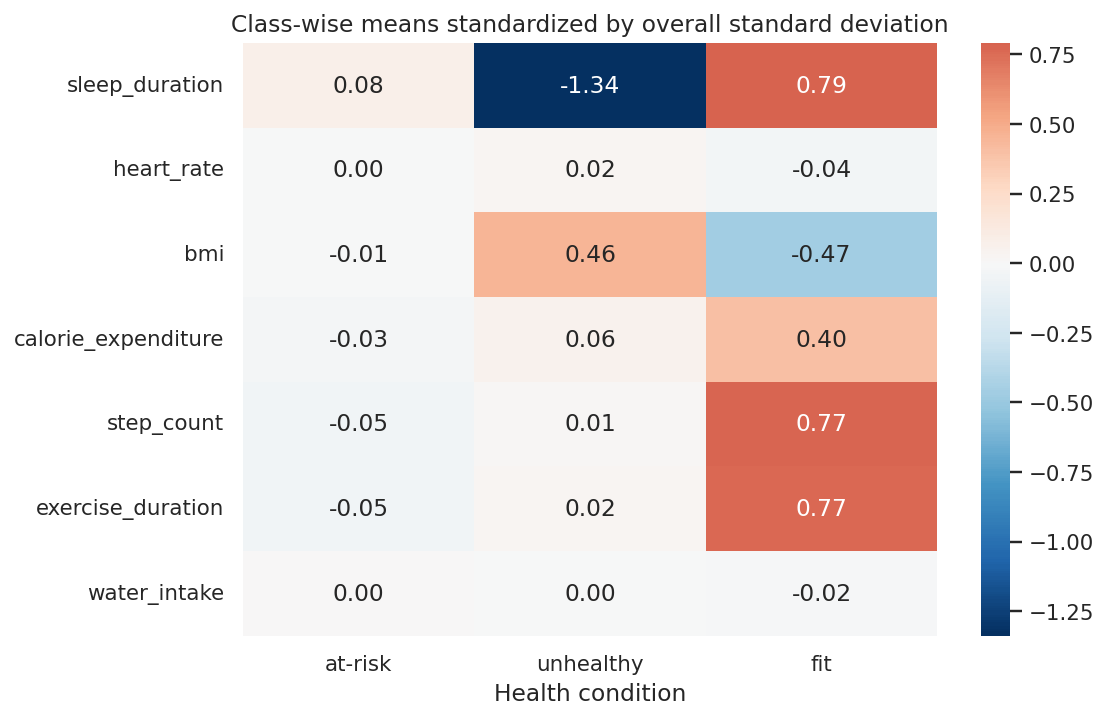

In [6]:
numeric_means = (
    train.groupby(target, observed=True)[numeric_features]
         .mean()
         .reindex(class_order)
         .T
)
display(numeric_means.round(2))

overall_mean = train[numeric_features].mean()
overall_std = train[numeric_features].std()
standardized_means = (
    numeric_means - overall_mean.values[:, None]
) / overall_std.values[:, None]

plt.figure(figsize=(8, 5.5))
sns.heatmap(standardized_means, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Class-wise means standardized by overall standard deviation')
plt.xlabel('Health condition')
plt.ylabel('')
plt.show()

### 해석

- 평균 수면시간은 `unhealthy` **5.37시간**, `at-risk` **7.09시간**, `fit` **7.95시간**으로 차이가 매우 크다.
- `fit` 집단은 평균 걸음 수와 운동시간이 가장 높고 BMI가 가장 낮다.
- `unhealthy` 집단은 평균 BMI가 가장 높다.
- `heart_rate`와 `water_intake`는 클래스별 평균 차이가 작아 단독 설명력은 제한적일 가능성이 있다.
- 선형적인 한 변수 효과뿐 아니라 수면·활동·스트레스 간 상호작용을 포착할 수 있는 트리 기반 부스팅 모델이 적합해 보인다.

## 5. 범주형 변수와 건강 상태의 관계

In [7]:
from scipy.stats import chi2_contingency

categorical_association_rows = []
for column in categorical_features:
    contingency = pd.crosstab(
        train[column].fillna('Missing'),
        train[target]
    )
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    denominator = n * min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / denominator)
    categorical_association_rows.append({
        'feature': column,
        'cramers_v': cramers_v,
    })

categorical_association = (
    pd.DataFrame(categorical_association_rows)
      .set_index('feature')
      .sort_values('cramers_v', ascending=False)
)
display(categorical_association.round(4))

# 연관성이 가장 큰 상위 3개 변수를 상세 시각화
key_categorical = categorical_association.head(3).index.tolist()
print('Selected variables:', key_categorical)

,cramers_v
feature,
stress_level,0.3870
physical_activity_level,0.2344
sleep_quality,0.1151
smoking_alcohol,0.0748
diet_type,0.0155
gender,0.0129


Selected variables: ['stress_level', 'physical_activity_level', 'sleep_quality']


### 범주형 변수 선정 기준

- 범주형 변수 6개를 모두 비교한 뒤, 타깃 `health_condition`과의 연관성을 **Cramér's V**로 계산했다.
- Cramér's V는 두 범주형 변수의 연관성 크기를 0 이상으로 나타내며, **0에 가까울수록 연관성이 약하고 값이 클수록 강하다.**
- 계산 결과 `stress_level`(0.3870), `physical_activity_level`(0.2344), `sleep_quality`(0.1151)가 상위 3개로 나타나 상세 히트맵 대상으로 선택했다.
- 이는 각 변수를 하나씩 타깃과 비교한 결과이며, 최종 모델의 변수 중요도나 인과관계를 의미하지 않는다.

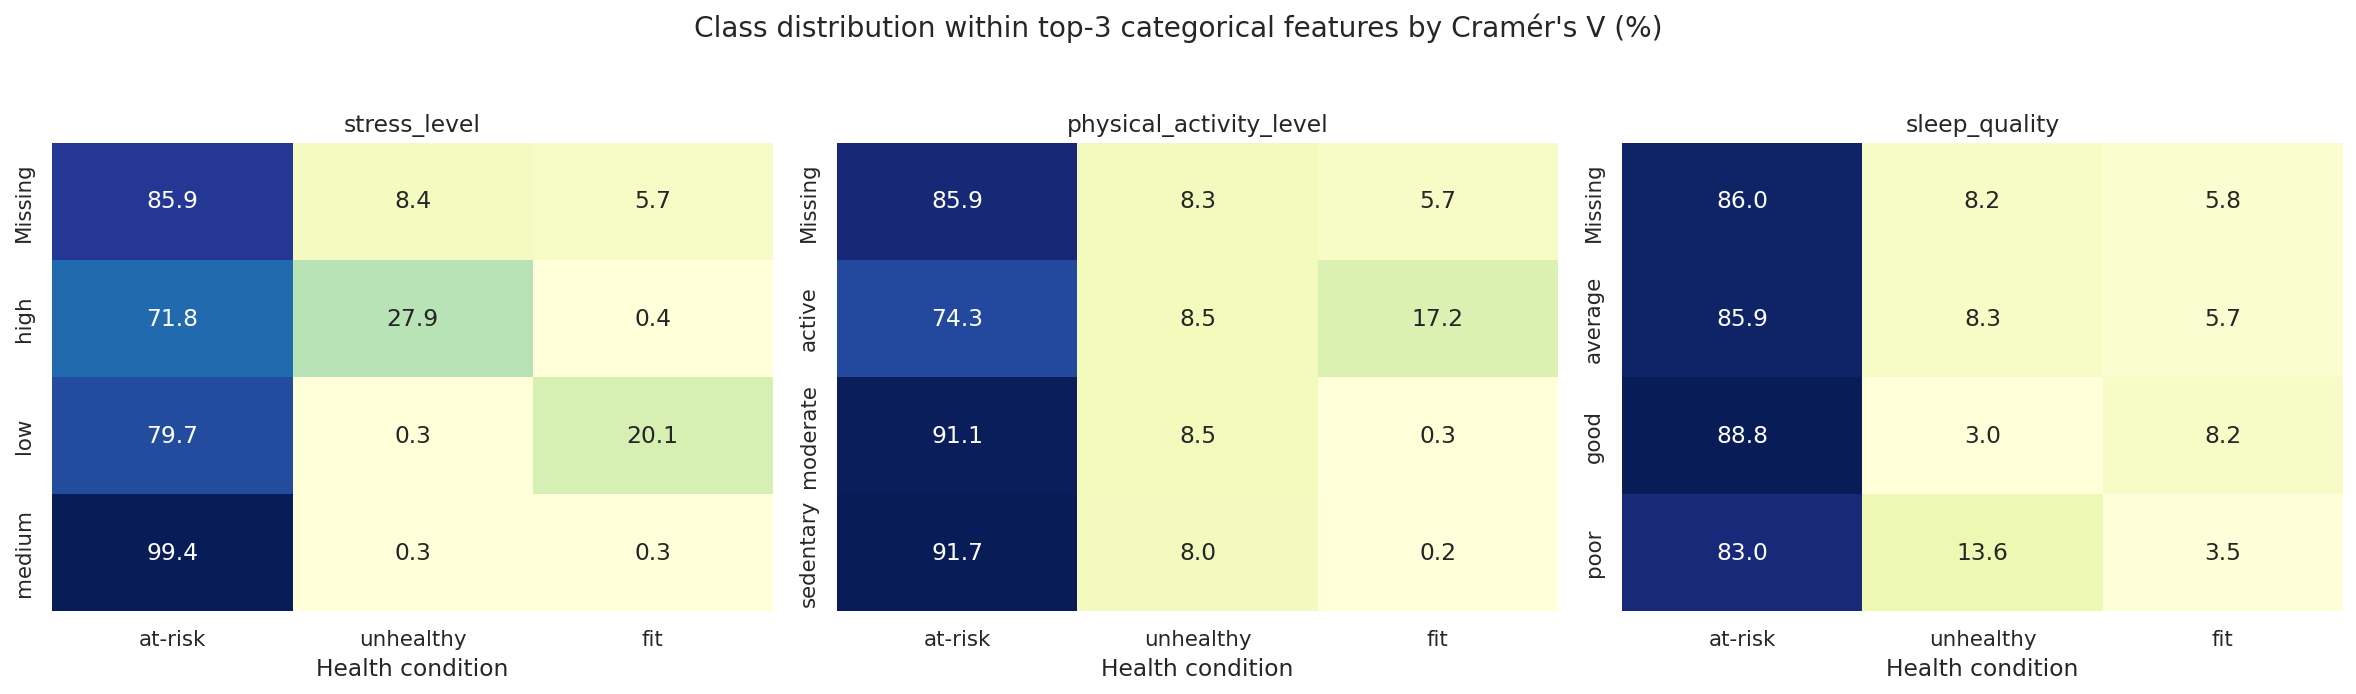

In [8]:
# Cramér's V가 높은 상위 3개 범주형 변수를 상세 확인
key_categorical = categorical_association.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, column in zip(axes, key_categorical):
    tab = pd.crosstab(
        train[column].fillna('Missing'),
        train[target],
        normalize='index'
    ).reindex(columns=class_order) * 100
    sns.heatmap(tab, annot=True, fmt='.1f', cmap='YlGnBu', cbar=False, ax=ax)
    ax.set_title(column)
    ax.set_xlabel('Health condition')
    ax.set_ylabel('')

fig.suptitle("Class distribution within top-3 categorical features by Cramér's V (%)", y=1.03)
plt.tight_layout()
plt.show()

### 해석

- `stress_level=medium`인 행의 **99.39%**가 `at-risk`다.
- `stress_level=high`에서는 `unhealthy` 비율이 **27.87%**, `stress_level=low`에서는 `fit` 비율이 **20.06%**로 증가한다.
- `physical_activity_level=active`에서는 `fit` 비율이 **17.16%**지만, `moderate`와 `sedentary`에서는 각각 약 **0.31%, 0.24%**다.
- 수면의 질이 나쁠 때 `unhealthy` 비율이 높아지고, 좋을 때 `fit` 비율이 높아진다.
- 특히 `stress_level`과 활동 관련 변수의 조합이 중요한 분기 조건이 될 가능성이 높다.

## 6. 숫자형 변수 간 상관관계

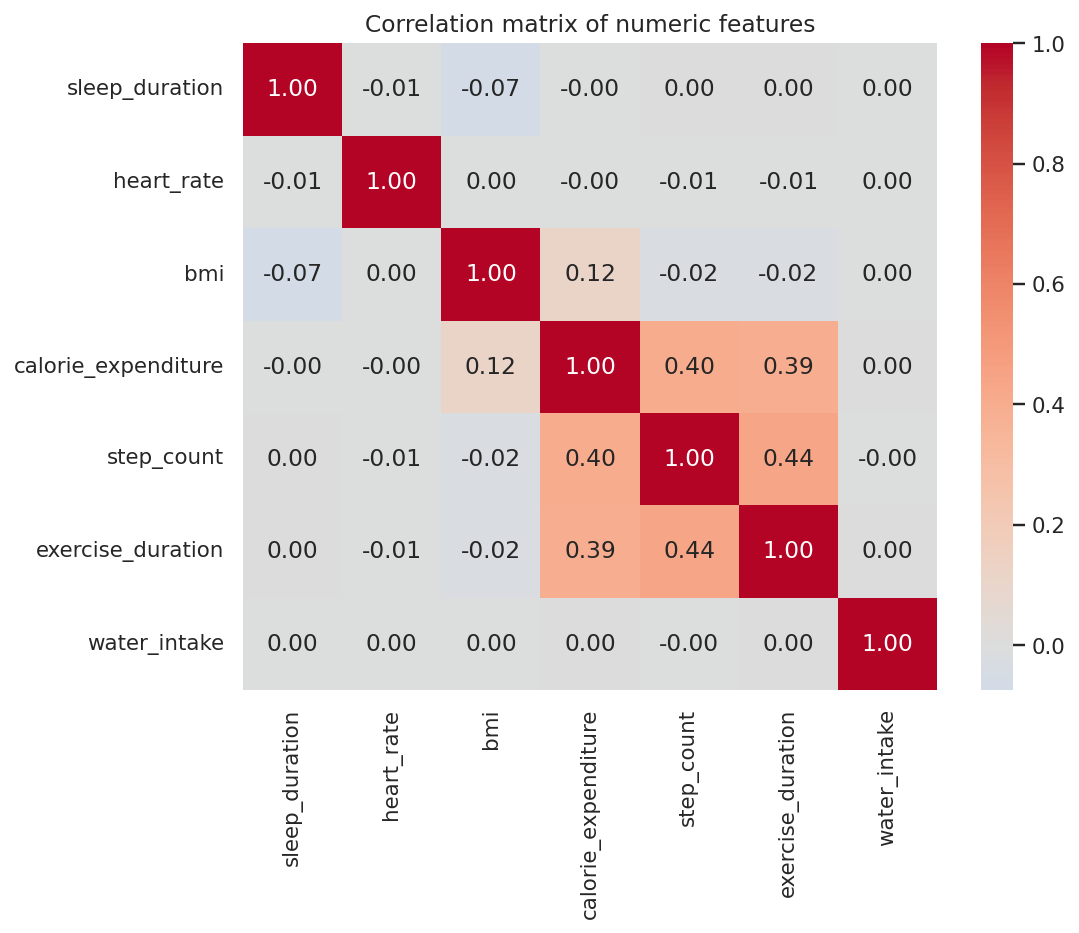

In [9]:
corr = train[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix of numeric features')
plt.show()

### 해석

- 걸음 수, 운동시간, 칼로리 소비량 사이에 약 0.39~0.44의 중간 정도 양의 상관관계가 있다.
- 나머지 변수끼리의 선형 상관은 대체로 낮다.
- 상관계수가 낮다고 예측력이 없다는 의미는 아니다. 타깃과의 비선형 관계와 범주형 변수와의 상호작용은 별도로 모델이 학습해야 한다.

## 7. Train/Test 분포 비교

In [10]:
missing_comparison = pd.DataFrame({
    'train_missing (%)': train[features].isna().mean() * 100,
    'test_missing (%)': test[features].isna().mean() * 100,
})
missing_comparison['difference (pp)'] = (
    missing_comparison['test_missing (%)'] - missing_comparison['train_missing (%)']
)

numeric_shift = pd.DataFrame({
    'train_mean': train[numeric_features].mean(),
    'test_mean': test[numeric_features].mean(),
})
numeric_shift['standardized_mean_diff'] = (
    numeric_shift['test_mean'] - numeric_shift['train_mean']
) / train[numeric_features].std()

print('Missing-rate comparison')
display(missing_comparison.round(4))
print('Numeric mean comparison')
display(numeric_shift.round(4))

Missing-rate comparison


,train_missing (%),test_missing (%),difference (pp)
sleep_duration,11.0129,11.0129,-0.0000
heart_rate,1.1351,1.1351,-0.0000
bmi,2.0139,2.0138,-0.0001
calorie_expenditure,7.6589,7.6591,0.0002
step_count,2.0166,2.0165,-0.0000
exercise_duration,1.0000,1.0002,0.0001
water_intake,6.3002,6.3002,-0.0000
diet_type,1.0000,1.0002,0.0001
stress_level,12.0001,11.9999,-0.0002
sleep_quality,8.4527,8.4527,-0.0000


Numeric mean comparison


,train_mean,test_mean,standardized_mean_diff
sleep_duration,6.9926,6.9935,0.0008
heart_rate,75.0965,75.0796,-0.0021
bmi,22.9849,22.9847,-0.0001
calorie_expenditure,2226.0849,2225.5149,-0.0016
step_count,8615.9531,8626.6305,0.0027
exercise_duration,38.7515,38.7967,0.0031
water_intake,2.1885,2.1915,0.0057


### 해석

- 모든 변수의 train/test 결측률 차이가 반올림 기준 거의 0%p다.
- 숫자형 변수의 표준화 평균 차이도 절댓값 0.006 미만이다.
- 단순 통계만으로는 뚜렷한 train/test 분포 이동이 보이지 않는다. 다만 모델링 단계에서 교차검증 점수와 제출 점수의 차이는 계속 확인해야 한다.

## 8. EDA 종합 결론

| 확인 내용 | 관찰 결과 | 모델링 반영 |
|---|---|---|
| 타깃 불균형 | `at-risk` 85.87%, `unhealthy` 8.36%, `fit` 5.77% | Stratified 분할, Balanced Accuracy, class weight 검토 |
| 결측치 | 모든 변수에 1~12% 존재 | 행 삭제 지양, 대체값 및 missing indicator 사용 |
| 핵심 변수 | 스트레스, 수면시간, 활동수준, BMI | 비선형 관계와 변수 상호작용을 학습하는 모델 사용 |
| 낮은 영향 후보 | 심박수, 수분 섭취량은 클래스 평균 차이가 작음 | 제거를 단정하지 않고 모델 중요도로 재확인 |
| 중복 | 완전히 동일한 행 없음 | 중복 제거 불필요 |
| Train/Test 차이 | 결측률과 숫자 평균이 거의 동일 | 기본적인 Stratified CV 사용 가능 |

## 9. 분류 모델 선택

### 현재 검증 결과와 제안

- **현재 로컬 검증 성능이 가장 높은 모델:** `LightGBMClassifier`
- **기준 모델:** `HistGradientBoostingClassifier`
- **Kaggle GPU에서 추가 검증할 후보:** `TabPFNClassifier` (TabPFN-3)

HistGradientBoosting과 LightGBM은 동일한 `train_test_split(..., stratify=y, random_state=42)`의 검증 행에서 직접 비교했다. LightGBM은 Balanced Accuracy **0.9498**로 HistGradientBoosting의 **0.9101**보다 높았다. 따라서 현재까지 직접 검증한 모델 중에서는 LightGBM을 주 모델로 제안한다.

TabPFN-3는 동일 대회의 공개 노트북에서 Kaggle 점수 **0.94688**을 기록했지만, 이는 Kaggle의 숨겨진 test 정답으로 측정된 점수다. 현재 로컬 환경에는 GPU와 TabPFN-3 모델이 없어 같은 20% 검증 행에서 실행하지 못했으므로, LightGBM과 직접적인 우열은 아직 판단하지 않는다.

### 모델별 역할과 현재 상태

| 모델 | 역할 | 현재 상태 | 결과 또는 한계 |
|---|---|---|---|
| HistGradientBoosting | 기준 모델 | 로컬 실행 완료 | 동일 20% 검증 세트 Balanced Accuracy 0.9101 |
| **LightGBM** | **현재 주 모델** | **로컬 실행 완료** | **동일 20% 검증 세트 Balanced Accuracy 0.9498** |
| TabPFN-3 | 추가 비교 후보 | 로컬 미실행 | 공개 Kaggle 점수 0.94688, GPU·모델 사용권 필요 |

### 점수 해석 시 주의

| 결과 | 평가 데이터 | 의미 |
|---|---|---|
| HistGradientBoosting 0.9101 | train의 20% 로컬 검증 세트 | 현재 노트북 파이프라인의 기준점 |
| LightGBM 0.9498 | **동일한** train의 20% 로컬 검증 세트 | HistGradientBoosting보다 높은 직접 비교 결과 |
| TabPFN-3 0.94688 | Kaggle 비공개 정답이 있는 리더보드 세트 | 공개 TabPFN 구현의 대회 성능 |

HistGradientBoosting과 LightGBM은 같은 검증 행을 사용했으므로 직접 비교할 수 있다. 반면 TabPFN-3의 0.94688은 평가한 행이 다르므로 로컬 점수와 직접 비교하지 않는다.

### 검증 계획

- `id` 제외
- 평가지표: `balanced_accuracy_score`
- 1차 비교 완료: 동일한 홀드아웃에서 HistGradientBoosting 0.9101, LightGBM 0.9498
- LightGBM: 다음 단계에서 5-fold Stratified 교차검증과 하이퍼파라미터 조정
- TabPFN-3: Kaggle GPU 환경에서 동일한 20% 홀드아웃으로 검증
- TabPFN-3 공개 설정인 `balance_probabilities=True`를 먼저 재현한 뒤, decision-threshold tuning은 별도 실험으로 분리
- 최종 제출 전 혼동행렬과 클래스별 Recall 확인

## 10. 빠른 기준 모델 실행

후보 모델을 본격적으로 비교하기 전, 추가 설치가 필요 없는 `HistGradientBoostingClassifier`로 전체 데이터의 20% 검증 점수를 확인한다. 이 결과는 최종 모델 성능이 아니라 **파이프라인이 정상 작동하는지 확인하는 기준점**이다.

Balanced accuracy: 0.9101
Ordinary accuracy: 0.8848
Boosting iterations: 138


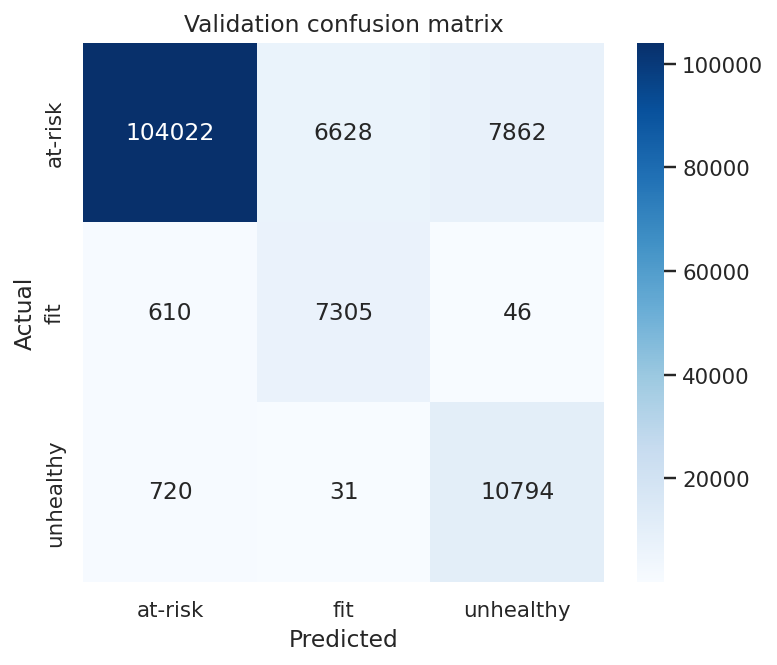

,precision,recall,f1-score,support
at-risk,0.9874,0.8777,0.9293,118512.0000
fit,0.5231,0.9176,0.6664,7961.0000
unhealthy,0.5772,0.9350,0.7137,11545.0000
accuracy,0.8848,0.8848,0.8848,0.8848
macro avg,0.6959,0.9101,0.7698,138018.0000
weighted avg,0.9263,0.8848,0.8961,138018.0000


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

X = train[features]
y = train[target]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
])

# 숫자형 7개 + 숫자형 결측 indicator 7개 뒤에 범주형 6개가 위치
categorical_mask = [False] * (len(numeric_features) * 2) + [True] * len(categorical_features)

baseline_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=180,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    class_weight='balanced',
    categorical_features=categorical_mask,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_model),
])
baseline_pipeline.fit(X_train, y_train)
valid_pred = baseline_pipeline.predict(X_valid)

baseline_score = balanced_accuracy_score(y_valid, valid_pred)
ordinary_accuracy = (valid_pred == y_valid).mean()
labels = baseline_pipeline.named_steps['model'].classes_

print(f'Balanced accuracy: {baseline_score:.4f}')
print(f'Ordinary accuracy: {ordinary_accuracy:.4f}')
print(f'Boosting iterations: {baseline_pipeline.named_steps["model"].n_iter_}')

cm = confusion_matrix(y_valid, valid_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

display(pd.DataFrame(classification_report(y_valid, valid_pred, output_dict=True)).T.round(4))

### 기준 모델 결과 해석

- 검증 Balanced Accuracy는 **0.9101**로, 모든 행을 다수 클래스인 `at-risk`로 예측했을 때의 약 0.333보다 높다.
- 희소 클래스인 `fit`과 `unhealthy`의 Recall은 높지만, 다수 클래스인 `at-risk`를 희소 클래스로 잘못 예측하는 경우가 남아 있다.
- 이 점수는 최종 후보 모델의 성능이 아니라 동일한 홀드아웃에서 다른 모델과 비교하기 위한 기준점이다.

## 11. LightGBM 동일 홀드아웃 비교

HistGradientBoosting과 공정하게 비교하기 위해 **동일한 80:20 분할**, `stratify=y`, `random_state=42`, `class_weight='balanced'`를 사용한다. LightGBM은 숫자형 결측치를 자체 처리하고, 범주형 변수는 pandas의 `category` 자료형으로 전달한다.

> 실행 환경에 LightGBM이 없다면 먼저 `pip install lightgbm`을 실행해야 한다.

Balanced accuracy: 0.9498
Ordinary accuracy: 0.9417
Boosting trees: 1000


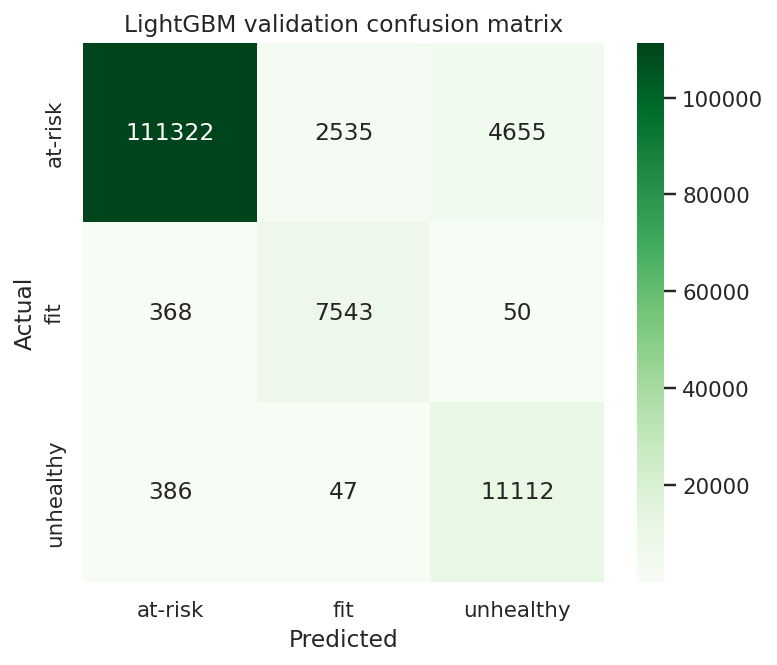

,precision,recall,f1-score,support
at-risk,0.9933,0.9393,0.9655,118512.0000
fit,0.7450,0.9475,0.8341,7961.0000
unhealthy,0.7025,0.9625,0.8122,11545.0000
accuracy,0.9417,0.9417,0.9417,0.9417
macro avg,0.8136,0.9498,0.8706,138018.0000
weighted avg,0.9546,0.9417,0.9451,138018.0000


In [12]:
# 설치되지 않은 환경에서는 먼저 실행: !pip install lightgbm
from lightgbm import LGBMClassifier

# LightGBM은 숫자형 NaN을 자체 처리하고 범주형 변수는 category로 인식
X_lgb = train[features].copy()
for column in categorical_features:
    X_lgb[column] = X_lgb[column].fillna('Missing').astype('category')

# HistGradientBoosting과 동일한 행이 검증 세트에 들어가도록 같은 설정 사용
X_lgb_train, X_lgb_valid, y_lgb_train, y_lgb_valid = train_test_split(
    X_lgb, y, test_size=0.2, stratify=y, random_state=42
)

lightgbm_model = LGBMClassifier(
    objective='multiclass',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
lightgbm_model.fit(
    X_lgb_train,
    y_lgb_train,
    categorical_feature=categorical_features,
)
lightgbm_pred = lightgbm_model.predict(X_lgb_valid)

lightgbm_score = balanced_accuracy_score(y_lgb_valid, lightgbm_pred)
lightgbm_accuracy = (lightgbm_pred == y_lgb_valid).mean()
lightgbm_labels = lightgbm_model.classes_

print(f'Balanced accuracy: {lightgbm_score:.4f}')
print(f'Ordinary accuracy: {lightgbm_accuracy:.4f}')
print(f'Boosting trees: {lightgbm_model.n_estimators_}')

lightgbm_cm = confusion_matrix(
    y_lgb_valid, lightgbm_pred, labels=lightgbm_labels
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    lightgbm_cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=lightgbm_labels, yticklabels=lightgbm_labels
)
plt.title('LightGBM validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

display(pd.DataFrame(
    classification_report(y_lgb_valid, lightgbm_pred, output_dict=True)
).T.round(4))

### LightGBM 결과 해석

- 동일한 20% 검증 세트에서 Balanced Accuracy는 **0.9498**, 일반 Accuracy는 **0.9417**다.
- HistGradientBoosting의 0.9101보다 Balanced Accuracy가 **0.0397**, 즉 약 **3.97%p** 높다.
- 클래스별 Recall은 `at-risk` **93.93%**, `fit` **94.75%**, `unhealthy` **96.25%**로 고르게 높다.
- 두 모델은 같은 검증 행과 같은 평가지표를 사용했으므로, 현재 조건에서는 **LightGBM이 더 우수하다**고 결론 내릴 수 있다.
- 다만 한 번의 홀드아웃 결과이므로, 최종 확정 전 5-fold Stratified 교차검증으로 안정성을 확인한다.

## 12. TabPFN-3 공개 구현 검토 및 반영

참고 노트북: [TabPFN-3 Starter: Playground Series S6E7](https://www.kaggle.com/code/philippsinger/tabpfn-3-starter-playground-series-s6e7?scriptVersionId=333096364&cellId=1)

공개 구현은 다음 설정으로 Kaggle 점수 **0.94688**을 기록했다.

- 원본 숫자형·범주형 변수를 그대로 사용하고 `id`만 제외
- 별도의 결측치 대체, 인코딩, 스케일링, 특성공학 없음
- `TabPFNClassifier(n_estimators=2, balance_probabilities=True, fit_mode='fit_with_cache')`
- Kaggle T4 GPU 2개 사용
- 시험 데이터를 100,000행 단위로 나누어 예측
- 총 실행시간 약 1시간 12분

공개 코드에 적힌 `eval_metric='balanced_accuracy'`와 decision-threshold tuning 부분은 실제 고득점 실행에서는 주석 처리되어 있었다. 따라서 우선 **실제로 0.94688을 만든 `balance_probabilities=True` 설정을 그대로 재현**하고, threshold tuning은 별도의 실험으로 비교하는 것이 타당하다.

Kaggle에서 실행하려면 먼저 TabPFN-3 모델 페이지의 사용권에 동의하고, 첫 셀에서 `!uv pip install tabpfn --system -q`를 실행해야 한다.

> **현재 실행 상태:** 이 환경에는 GPU와 TabPFN-3 패키지·모델이 없어 로컬 Balanced Accuracy를 측정하지 못했다. 따라서 공개 Kaggle 점수는 참고값으로만 두고, Kaggle GPU에서 동일한 20% 검증 행으로 다시 측정해야 LightGBM과 직접 비교할 수 있다.

In [ ]:
# Kaggle T4 x2 환경에서 실행하는 TabPFN-3 재현 코드
import os
from pathlib import Path
from tabpfn import TabPFNClassifier

model_cache = Path('/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1')
if model_cache.exists():
    os.environ['TABPFN_MODEL_CACHE_DIR'] = str(model_cache)

tabpfn_train = pd.read_csv(data_dir / 'train.csv', index_col='id')
tabpfn_y = tabpfn_train.pop('health_condition')
tabpfn_test = pd.read_csv(data_dir / 'test.csv', index_col='id')

tabpfn_model = TabPFNClassifier(
    device=['cuda:0', 'cuda:1'],  # GPU 1개라면 device='cuda'
    n_estimators=2,
    balance_probabilities=True,
    fit_mode='fit_with_cache',
)
tabpfn_model.fit(tabpfn_train, tabpfn_y)

# DataFrame 형태를 유지해 공개 코드에서 발생한 feature-name 경고를 방지
tabpfn_predictions = []
chunk_size = 100_000
for start in range(0, len(tabpfn_test), chunk_size):
    chunk = tabpfn_test.iloc[start:start + chunk_size]
    tabpfn_predictions.append(tabpfn_model.predict(chunk))

tabpfn_predictions = np.concatenate(tabpfn_predictions)

tabpfn_submission = sample_submission.copy()
tabpfn_submission['health_condition'] = tabpfn_predictions
tabpfn_submission.to_csv('submission_tabpfn3.csv', index=False)
tabpfn_submission.head()

### 공개 코드에서 수정한 부분

공개 노트북은 예측 전에 `test.to_numpy()`로 변환해서 학습 때 사용한 열 이름이 사라졌고, 이에 따라 feature-name 경고가 발생했다. 위 코드에서는 `DataFrame.iloc`로 10만 행씩 나누어 **열 이름과 순서를 유지한 채 예측**하도록 수정했다. 모델 설정과 청크 크기는 0.94688을 기록한 실행과 동일하게 유지했다.

TabPFN-3 자체의 전처리 기능을 살리기 위해 기존 EDA에서 제안했던 중앙값 대체나 범주형 인코딩은 적용하지 않는다. 반면 LightGBM과 HistGradientBoosting에는 각 모델에 맞는 별도의 전처리 파이프라인을 사용한다.

## 13. 회의 공유용 한 문단

> 학습 데이터는 690,088행과 13개의 예측 변수로 구성되어 있으며, 타깃은 at-risk 85.87%, unhealthy 8.36%, fit 5.77%로 심하게 불균형했습니다. 모든 변수에 1~12%의 결측치가 존재했고, 스트레스 수준·수면시간·신체활동 수준·BMI에서 클래스별 차이가 크게 나타났습니다. 동일한 20% Stratified 홀드아웃에서 HistGradientBoosting은 Balanced Accuracy 0.9101, LightGBM은 0.9498을 기록해 현재까지는 LightGBM의 성능이 더 높았습니다. 따라서 LightGBM을 현재 주 모델로 제안합니다. 공개 TabPFN-3 구현은 Kaggle 점수 0.94688을 기록했지만 평가 데이터가 다르므로 직접 비교하지 않고, 추후 Kaggle GPU에서 동일한 로컬 검증 세트로 확인할 예정입니다.